In [2]:
#import of libraries 
import pandas as pd
import numpy as  np 
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3


In [3]:
#Ingestion layer
#loading of the data 
df = pd.read_csv("Crime_Data_from_2020_to_2024.csv")

#checking data info 
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

In [4]:
#understanding the data 
print(df.head())

       DR_NO               Date Rptd                DATE OCC  TIME OCC  AREA  \
0  211507896  04/11/2021 12:00:00 AM  11/07/2020 12:00:00 AM       845    15   
1  201516622  10/21/2020 12:00:00 AM  10/18/2020 12:00:00 AM      1845    15   
2  240913563  12/10/2024 12:00:00 AM  10/30/2020 12:00:00 AM      1240     9   
3  210704711  12/24/2020 12:00:00 AM  12/24/2020 12:00:00 AM      1310     7   
4  201418201  10/03/2020 12:00:00 AM  09/29/2020 12:00:00 AM      1830    14   

     AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
0  N Hollywood         1502         2     354   
1  N Hollywood         1521         1     230   
2     Van Nuys          933         2     354   
3     Wilshire          782         1     331   
4      Pacific         1454         1     420   

                                         Crm Cd Desc  ... Status  Status Desc  \
0                                  THEFT OF IDENTITY  ...     IC  Invest Cont   
1     ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT  ...     

In [5]:
#dropping less important columns 
df.drop(columns=["Crm Cd 1",
                    "Crm Cd 2",
                    "Crm Cd 3",
                    "Crm Cd 4",
                    "Cross Street",
                    "LAT",
                    "LON",
                    "DR_NO",
                    "Rpt Dist No" ,
                    "Part 1-2" ,               
                    "Crm Cd",
                    "Status",
                    "Premis Cd",
                    "Vict Descent",
                    "Weapon Used Cd",
                    "LOCATION"],
                    inplace=True)

In [6]:
# checking duplicates
print(df.duplicated().sum())
#dropping the duplicate
df.drop_duplicates(inplace=True)


4875


In [7]:
#checking the missing values 
print(df.isnull().sum())
#dropping the missing value because the impact to the result from data is equal to none
df.dropna(inplace=True)


Date Rptd           0
DATE OCC            0
TIME OCC            0
AREA                0
AREA NAME           0
Crm Cd Desc         0
Mocodes        148726
Vict Age            0
Vict Sex       141801
Premis Desc       587
Weapon Desc    673906
Status Desc         0
dtype: int64


In [8]:
#converting time proper
df["TIME OCC"] = df["TIME OCC"].astype(str).str.zfill(4)
df["hour"] = df["TIME OCC"].str[:2].astype(int)
def time_of_day(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 21:
        return "evening"
    else:
        return "night"

df["time_category"] = df["hour"].apply(time_of_day)

# Remove ' 12:00:00 AM' from the date column
df["DATE OCC"]=df["DATE OCC"].str.replace(' 12:00:00 AM', '', regex=True)
df["Date Rptd"]=df["Date Rptd"].str.replace("12:00:00 AM "," ",regex=True)
#converting dates 
df["DATE OCC"]=pd.to_datetime(df["DATE OCC"])
df["Date Rptd"]=pd.to_datetime(df["Date Rptd"])

/tmp/ipykernel_41692/2558855930.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date Rptd"]=pd.to_datetime(df["Date Rptd"])


In [9]:
#cleaning the location columns 
#area ,area_name ,premise desc 
df["AREA"]=pd.to_numeric(df["AREA"],errors ="coerce")
df["AREA NAME"]=df["AREA NAME"].str.strip().str.lower()
df["Premis Desc"]=df["Premis Desc"].str.strip().str.lower()
def categorize_location(x):
    if "dwelling" in x or "apartment" in x:
        return "residential"
    elif "store" in x or "restaurant" in x:
        return "commercial"
    elif "street" in x or "parking" in x:
        return "public"
    else:
        return "other"


df["location_category"] = df["Premis Desc"].apply(categorize_location)

In [10]:
#handling mocode
df["Mocodes"] = df["Mocodes"].str.split(" ")
df = df.explode("Mocodes")

In [11]:
#renaming columns
df.rename(columns={
    'Date Rptd'   : 'date_reported',
    'DATE OCC'    : 'date_occurred',
    'TIME OCC'    : 'time_occurred',
    'AREA'        : 'area_id',
    'AREA NAME'   : 'area_name',
    'Crm Cd Desc' : 'crime_description',
    'Mocodes'     : 'modus_operandi',
    'Vict Age'    : 'victim_age',
    'Vict Sex'    : 'victim_sex',
    'Premis Desc' : 'premise_description',
    'Weapon Desc' : 'weapon_description',
    'Status Des'  : 'status_description'
}, inplace=True)

In [12]:
#data storage
df.to_csv("cleaned_lapd_crime.csv")
conn = sqlite3.connect("crime.db")
conn.execute("""CREATE TABLE IF NOT EXISTS crime_data (
    id INTEGER PRIMARY KEY AUTOINCREMENT,

    date_reported DATE NOT NULL,
    date_occurred DATE NOT NULL,
    time_occurred TIME NOT NULL,

    area INTEGER NOT NULL,
    area_name TEXT NOT NULL,

    crime_description TEXT NOT NULL,

    mocodes TEXT,              -- nullable
    victim_age INTEGER NOT NULL,
    victim_sex TEXT,           -- nullable

    premise_description TEXT,  -- nullable
    weapon_description TEXT,   -- nullable

    status_description TEXT NOT NULL
);

             """)
conn.commit()

In [13]:
df.to_sql('crime_data', conn, if_exists='replace', index=False)

1555910

In [14]:
pd.read_sql("""SELECT * 
            FROM crime_data

""",conn)

,date_reported,date_occurred,time_occurred,area_id,area_name,crime_description,modus_operandi,victim_age,victim_sex,premise_description,weapon_description,Status Desc,hour,time_category,location_category
0,2020-10-21 00:00:00,2020-10-18 00:00:00,1845,15,n hollywood,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416,32,M,sidewalk,KNIFE WITH BLADE 6INCHES OR LESS,Invest Cont,18,evening,other
1,2020-10-21 00:00:00,2020-10-18 00:00:00,1845,15,n hollywood,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0334,32,M,sidewalk,KNIFE WITH BLADE 6INCHES OR LESS,Invest Cont,18,evening,other
2,2020-10-21 00:00:00,2020-10-18 00:00:00,1845,15,n hollywood,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",2004,32,M,sidewalk,KNIFE WITH BLADE 6INCHES OR LESS,Invest Cont,18,evening,other
3,2020-10-21 00:00:00,2020-10-18 00:00:00,1845,15,n hollywood,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1822,32,M,sidewalk,KNIFE WITH BLADE 6INCHES OR LESS,Invest Cont,18,evening,other
4,2020-10-21 00:00:00,2020-10-18 00:00:00,1845,15,n hollywood,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1414,32,M,sidewalk,KNIFE WITH BLADE 6INCHES OR LESS,Invest Cont,18,evening,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1555905,2024-04-24 00:00:00,2024-04-24 00:00:00,1500,3,southwest,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0334,70,F,sidewalk,STICK,Invest Cont,15,afternoon,other
1555906,2024-04-24 00:00:00,2024-04-24 00:00:00,1500,3,southwest,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416,70,F,sidewalk,STICK,Invest Cont,15,afternoon,other
1555907,2024-04-24 00:00:00,2024-04-24 00:00:00,1500,3,southwest,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0445,70,F,sidewalk,STICK,Invest Cont,15,afternoon,other
1555908,2024-04-24 00:00:00,2024-04-24 00:00:00,1500,3,southwest,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0449,70,F,sidewalk,STICK,Invest Cont,15,afternoon,other


In [29]:
#crime by area
pd.read_sql("""SELECT area_name ,COUNT(*) AS TOTAL
            FROM crime_data
            GROUP BY area_name
            ORDER BY TOTAL DESC
            LIMIT 20 




;""",conn)


,area_name,TOTAL
0,77th street,151627
1,southeast,129587
2,southwest,120841
3,central,113698
4,rampart,100561
5,hollywood,100497
6,olympic,95968
7,newton,89905
8,harbor,72508
9,west valley,71018


/tmp/ipykernel_41692/351538861.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TOTAL", y="area_name", data=top_areas, palette="viridis")


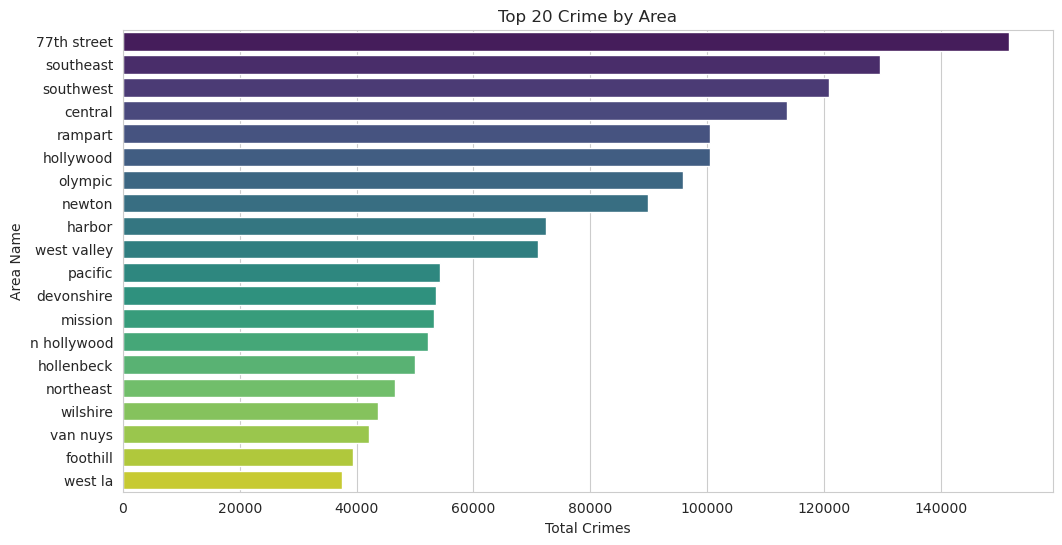

In [30]:
#plotting top 20 crime by area
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
top_areas = pd.read_sql("""SELECT area_name ,COUNT(*) AS TOTAL
            FROM crime_data
            GROUP BY area_name
            ORDER BY TOTAL DESC
            LIMIT 20
;""",conn)
sns.barplot(x="TOTAL", y="area_name", data=top_areas, palette="viridis")
plt.title("Top 20 Crime by Area")
plt.xlabel("Total Crimes")
plt.ylabel("Area Name")
plt.show()


In [ ]:
#top 20 number of crime description
pd.read_sql("""SELECT crime_description , COUNT(*) AS TOTAL
            FROM crime_data
            GROUP BY crime_description
            ORDER BY TOTAL DESC
            LIMIT 20
;""",conn)



,crime_description,TOTAL
0,BATTERY - SIMPLE ASSAULT,286503
1,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",286487
2,INTIMATE PARTNER - SIMPLE ASSAULT,239395
3,ROBBERY,206810
4,INTIMATE PARTNER - AGGRAVATED ASSAULT,83238
5,CRIMINAL THREATS - NO WEAPON DISPLAYED,74494
6,BRANDISH WEAPON,70841
7,BURGLARY,29259
8,ATTEMPTED ROBBERY,26788
9,"RAPE, FORCIBLE",26304


/tmp/ipykernel_41692/2712700659.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TOTAL", y="crime_description", data=top_crimes, palette="magma")


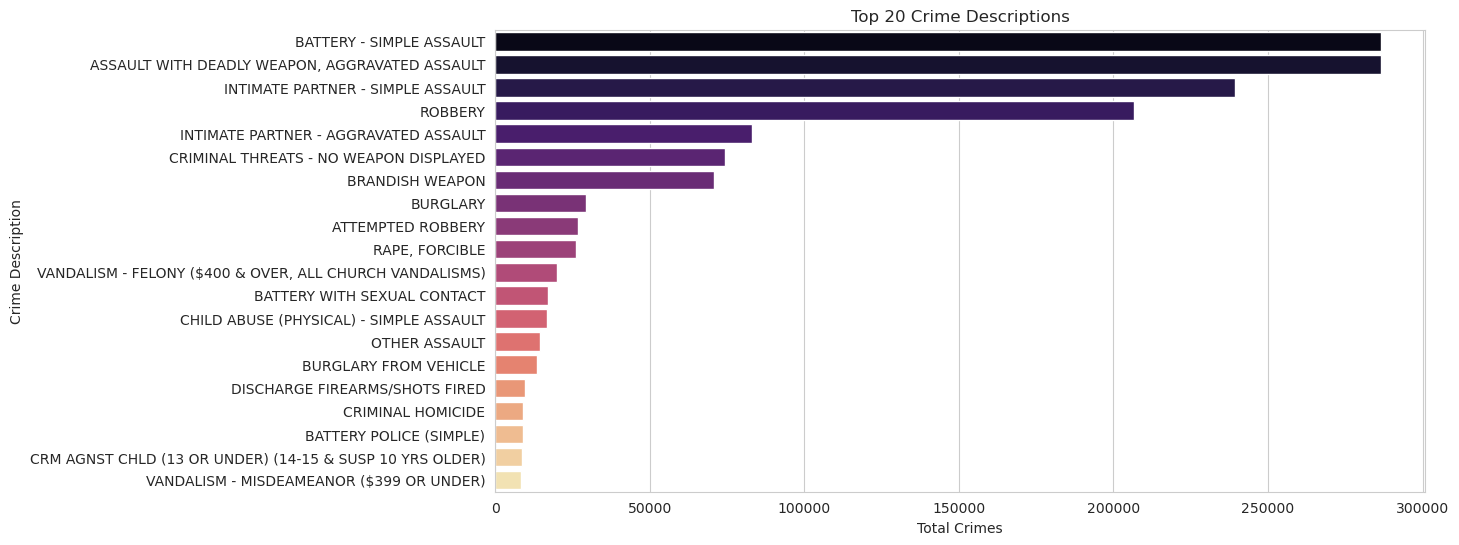

In [31]:
#plotting top 20 crime description
plt.figure(figsize=(12, 6))
top_crimes = pd.read_sql("""SELECT crime_description , COUNT(*) AS TOTAL
            FROM crime_data             
            GROUP BY crime_description
            ORDER BY TOTAL DESC
            LIMIT 20
;""",conn)
sns.barplot(x="TOTAL", y="crime_description", data=top_crimes, palette="magma")
plt.title("Top 20 Crime Descriptions")
plt.xlabel("Total Crimes")
plt.ylabel("Crime Description")
plt.show()

In [ ]:
#the premises count
pd.read_sql("""SELECT premise_description ,COUNT (*) AS Total
            FROM crime_data
            GROUP BY premise_description 
            ORDER BY Total desc
            LIMIT 20


;""",conn)

,premise_description,Total
0,street,348229
1,single family dwelling,281342
2,"multi-unit dwelling (apartment, duplex, etc)",262474
3,sidewalk,156200
4,parking lot,87074
5,other business,50674
6,"vehicle, passenger/truck",20035
7,restaurant/fast food,19408
8,alley,18805
9,park/playground,16383


/tmp/ipykernel_41692/2963235845.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Total", y="premise_description", data=top_premises, palette="coolwarm")


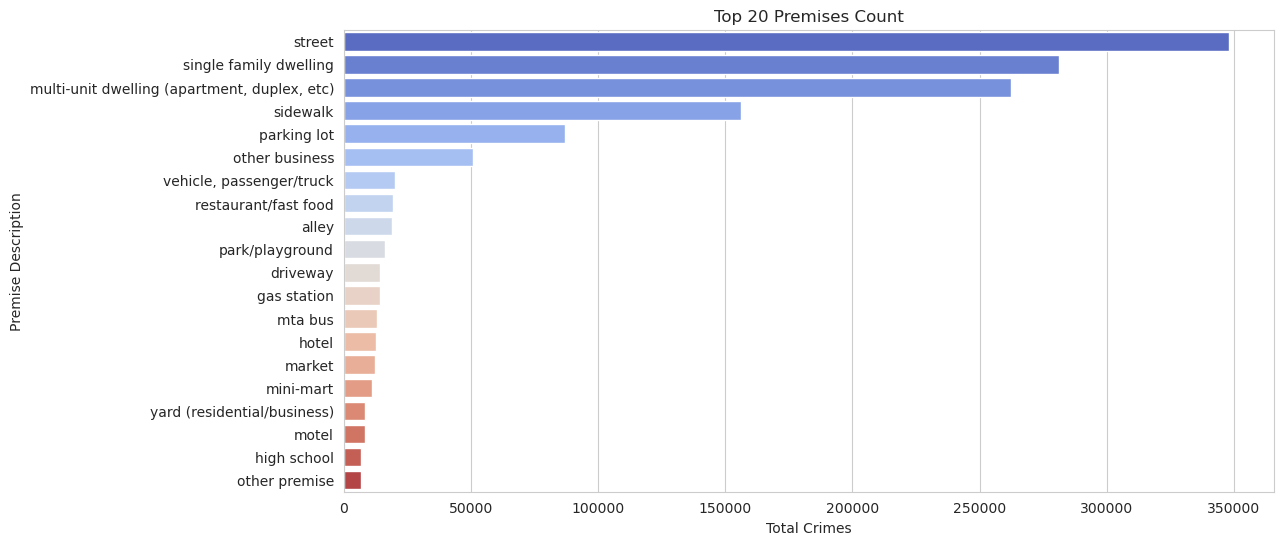

In [32]:
#plotting top 20 premises count
plt.figure(figsize=(12, 6))
top_premises = pd.read_sql("""SELECT premise_description ,COUNT (*) AS Total
                            FROM crime_data
                            GROUP BY premise_description
                            ORDER BY Total DESC
                            LIMIT 20
;""",conn)
sns.barplot(x="Total", y="premise_description", data=top_premises, palette="coolwarm")
plt.title("Top 20 Premises Count")
plt.xlabel("Total Crimes")
plt.ylabel("Premise Description")
plt.show()

In [ ]:
#TOP 20 WEAPONS USED
pd.read_sql("""SELECT weapon_description ,COUNT(*) AS TOTAL
            FROM crime_data
            GROUP BY weapon_description 
            ORDER BY TOTAL DESC
            LIMIT 20


;""",conn)

,weapon_description,TOTAL
0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",819623
1,UNKNOWN WEAPON/OTHER WEAPON,146262
2,HAND GUN,119203
3,VERBAL THREAT,95085
4,SEMI-AUTOMATIC PISTOL,45374
5,KNIFE WITH BLADE 6INCHES OR LESS,37970
6,UNKNOWN FIREARM,32746
7,OTHER KNIFE,30768
8,MACE/PEPPER SPRAY,17204
9,VEHICLE,16064


/tmp/ipykernel_41692/434334989.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TOTAL", y="weapon_description", data=top_weapons, palette="viridis")


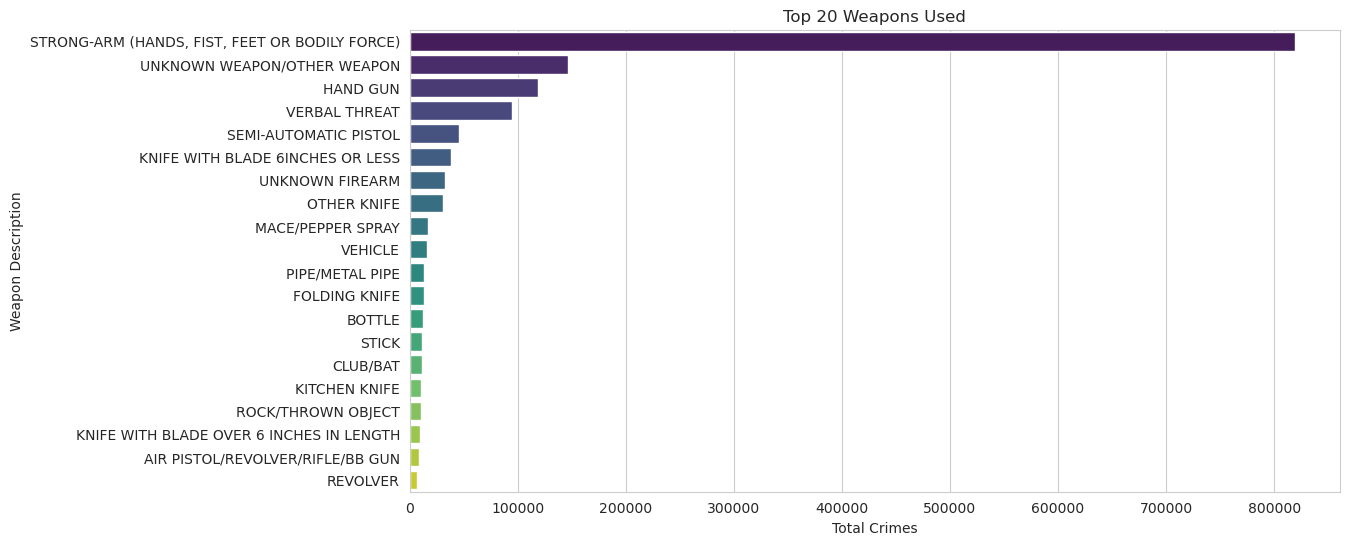

In [33]:
#plotting to 20 weapons used
plt.figure(figsize=(12, 6))
top_weapons = pd.read_sql("""SELECT weapon_description ,COUNT(*) AS TOTAL
                            FROM crime_data
                            GROUP BY weapon_description
                            ORDER BY TOTAL DESC
                            LIMIT 20
;""",conn)
sns.barplot(x="TOTAL", y="weapon_description", data=top_weapons, palette="viridis")
plt.title("Top 20 Weapons Used")
plt.xlabel("Total Crimes")
plt.ylabel("Weapon Description")
plt.show()

In [ ]:
#total crime by hour
pd.read_sql("""SELECT   hour ,COUNT(*)AS TOTAL
            FROM crime_data 
            GROUP BY hour
            
            LIMIT 24 
            



""",conn)

,hour,TOTAL
0,0,68046
1,1,57960
2,2,50288
3,3,38788
4,4,30620
5,5,25746
6,6,28181
7,7,36585
8,8,49713
9,9,52512


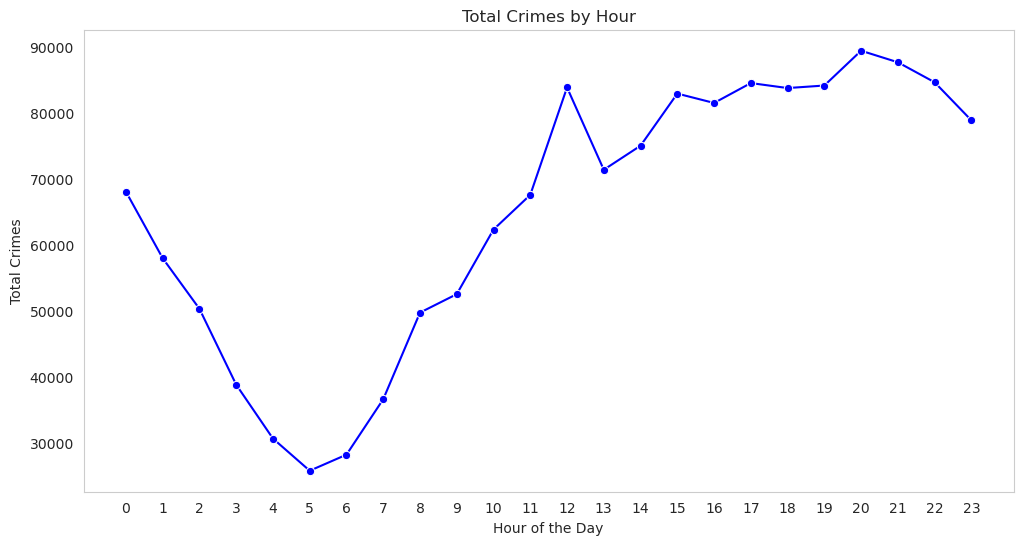

In [35]:
#plotting crime by hour
plt.figure(figsize=(12, 6))
crime_by_hour = pd.read_sql("""SELECT   hour ,COUNT(*)AS TOTAL
                            FROM crime_data
                            GROUP BY hour
                            LIMIT 24
;""",conn)
sns.lineplot(x="hour", y="TOTAL", data=crime_by_hour, marker="o", color="blue")
plt.title("Total Crimes by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Total Crimes")
plt.xticks(range(0, 24))
plt.grid()
plt.show()